<a href="https://colab.research.google.com/github/DinaRagab98/GDG_Data_Science_Project/blob/main/Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seismic Bumps Dataset

The **Seismic Bumps Dataset** is a multivariate classification dataset provided by the **UCI Machine Learning Repository**. It contains information about seismic activity recorded in underground coal mines in Poland.

Each record represents a summary of the seismic activity observed during an **8-hour work shift**. The dataset includes several measurements related to seismic energy, the number of seismic pulses and bumps, maximum recorded energy, and seismic hazard assessments.

The main objective is to **predict whether a hazardous seismic event will occur during the following shift**. A hazardous event is defined as a seismic bump with an energy greater than **10⁴ Joules**.

The target variable, `class`, is binary:

* **0 — Non-hazardous state:** No high-energy seismic bump occurred during the next shift.
* **1 — Hazardous state:** A high-energy seismic bump occurred during the next shift.

The dataset contains **2,584 observations and 18 input features**, making it a **binary classification problem**. One of the main challenges is the significant **class imbalance**, as only 170 observations belong to the hazardous class.

This dataset can therefore be used to investigate how machine learning models can identify patterns in seismic activity and provide an early indication of potentially hazardous conditions in underground mining operations.
<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTnadinE-XXkbCuiLWKdoS9zktQ_Dlrqr4ejOyUX6_Uzg&s=10" width="1000" height="500">

# Data Loading & Understanding

In [106]:
df=pd.read_csv('/content/csv_result-seismic-bumps.csv')
df.head() # Display the first 5 rows

,id,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,1,a,a,N,15180,48,-72,-72,a,0,0,0,0,0,0,0,0,0,0,0
1,2,a,a,N,14720,33,-70,-79,a,1,0,1,0,0,0,0,0,2000,2000,0
2,3,a,a,N,8050,30,-81,-78,a,0,0,0,0,0,0,0,0,0,0,0
3,4,a,a,N,28820,171,-23,40,a,1,0,1,0,0,0,0,0,3000,3000,0
4,5,a,a,N,12640,57,-63,-52,a,0,0,0,0,0,0,0,0,0,0,0


In [107]:
# check the shape of data
print("shape:", df.shape)
print('='*50)
# Display all column names
print("Column names:\n",df.columns.tolist())
print('='*50)
# get info
df.info()

shape: (2584, 20)
Column names:
 ['id', 'seismic', 'seismoacoustic', 'shift', 'genergy', 'gpuls', 'gdenergy', 'gdpuls', 'ghazard', 'nbumps', 'nbumps2', 'nbumps3', 'nbumps4', 'nbumps5', 'nbumps6', 'nbumps7', 'nbumps89', 'energy', 'maxenergy', 'class']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2584 entries, 0 to 2583
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              2584 non-null   int64 
 1   seismic         2584 non-null   object
 2   seismoacoustic  2584 non-null   object
 3   shift           2584 non-null   object
 4   genergy         2584 non-null   int64 
 5   gpuls           2584 non-null   int64 
 6   gdenergy        2584 non-null   int64 
 7   gdpuls          2584 non-null   int64 
 8   ghazard         2584 non-null   object
 9   nbumps          2584 non-null   int64 
 10  nbumps2         2584 non-null   int64 
 11  nbumps3         2584 non-null   int64 
 12  nbumps4         2584 

In [108]:
# statistical summary for numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,2584.0,1292.500000,746.080871,1.0,646.75,1292.5,1938.25,2584.0
genergy,2584.0,90242.523220,229200.508894,100.0,11660.00,25485.0,52832.50,2595650.0
gpuls,2584.0,538.579334,562.652536,2.0,190.00,379.0,669.00,4518.0
gdenergy,2584.0,12.375774,80.319051,-96.0,-37.00,-6.0,38.00,1245.0
gdpuls,2584.0,4.508901,63.166556,-96.0,-36.00,-6.0,30.25,838.0
nbumps,2584.0,0.859520,1.364616,0.0,0.00,0.0,1.00,9.0
nbumps2,2584.0,0.393576,0.783772,0.0,0.00,0.0,1.00,8.0
nbumps3,2584.0,0.392802,0.769710,0.0,0.00,0.0,1.00,7.0
nbumps4,2584.0,0.067724,0.279059,0.0,0.00,0.0,0.00,3.0
nbumps5,2584.0,0.004644,0.068001,0.0,0.00,0.0,0.00,1.0


In [109]:
# summary statistical for categorical columns
df.describe(include='object').T

,count,unique,top,freq
seismic,2584,2,a,1682
seismoacoustic,2584,3,a,1580
shift,2584,2,W,1663
ghazard,2584,3,a,2342


In [110]:
categorical_cols=df.select_dtypes(include='object').columns # categorical columns
# get values of each categorical columns
for col in categorical_cols:
  print('Column: ',col)
  print('Values:\n',df[col].value_counts())
  print('='*60)


Column:  seismic
Values:
 seismic
a    1682
b     902
Name: count, dtype: int64
Column:  seismoacoustic
Values:
 seismoacoustic
a    1580
b     956
c      48
Name: count, dtype: int64
Column:  shift
Values:
 shift
W    1663
N     921
Name: count, dtype: int64
Column:  ghazard
Values:
 ghazard
a    2342
b     212
c      30
Name: count, dtype: int64


Calculate the percentage of target class

In [111]:
print("Target class percentages: \n",df['class'].value_counts(normalize=True)*100)


Target class percentages: 
 class
0    93.421053
1     6.578947
Name: proportion, dtype: float64


There are implcanced data as class 1 represents 6.58% from data

check null values and duplicates

In [112]:
# check nulls
print('number of null values= ',df.isnull().sum().sum())

# check duplicates
print('number of duplicates= ',df.duplicated().sum())

number of null values=  0
number of duplicates=  0


check outliers

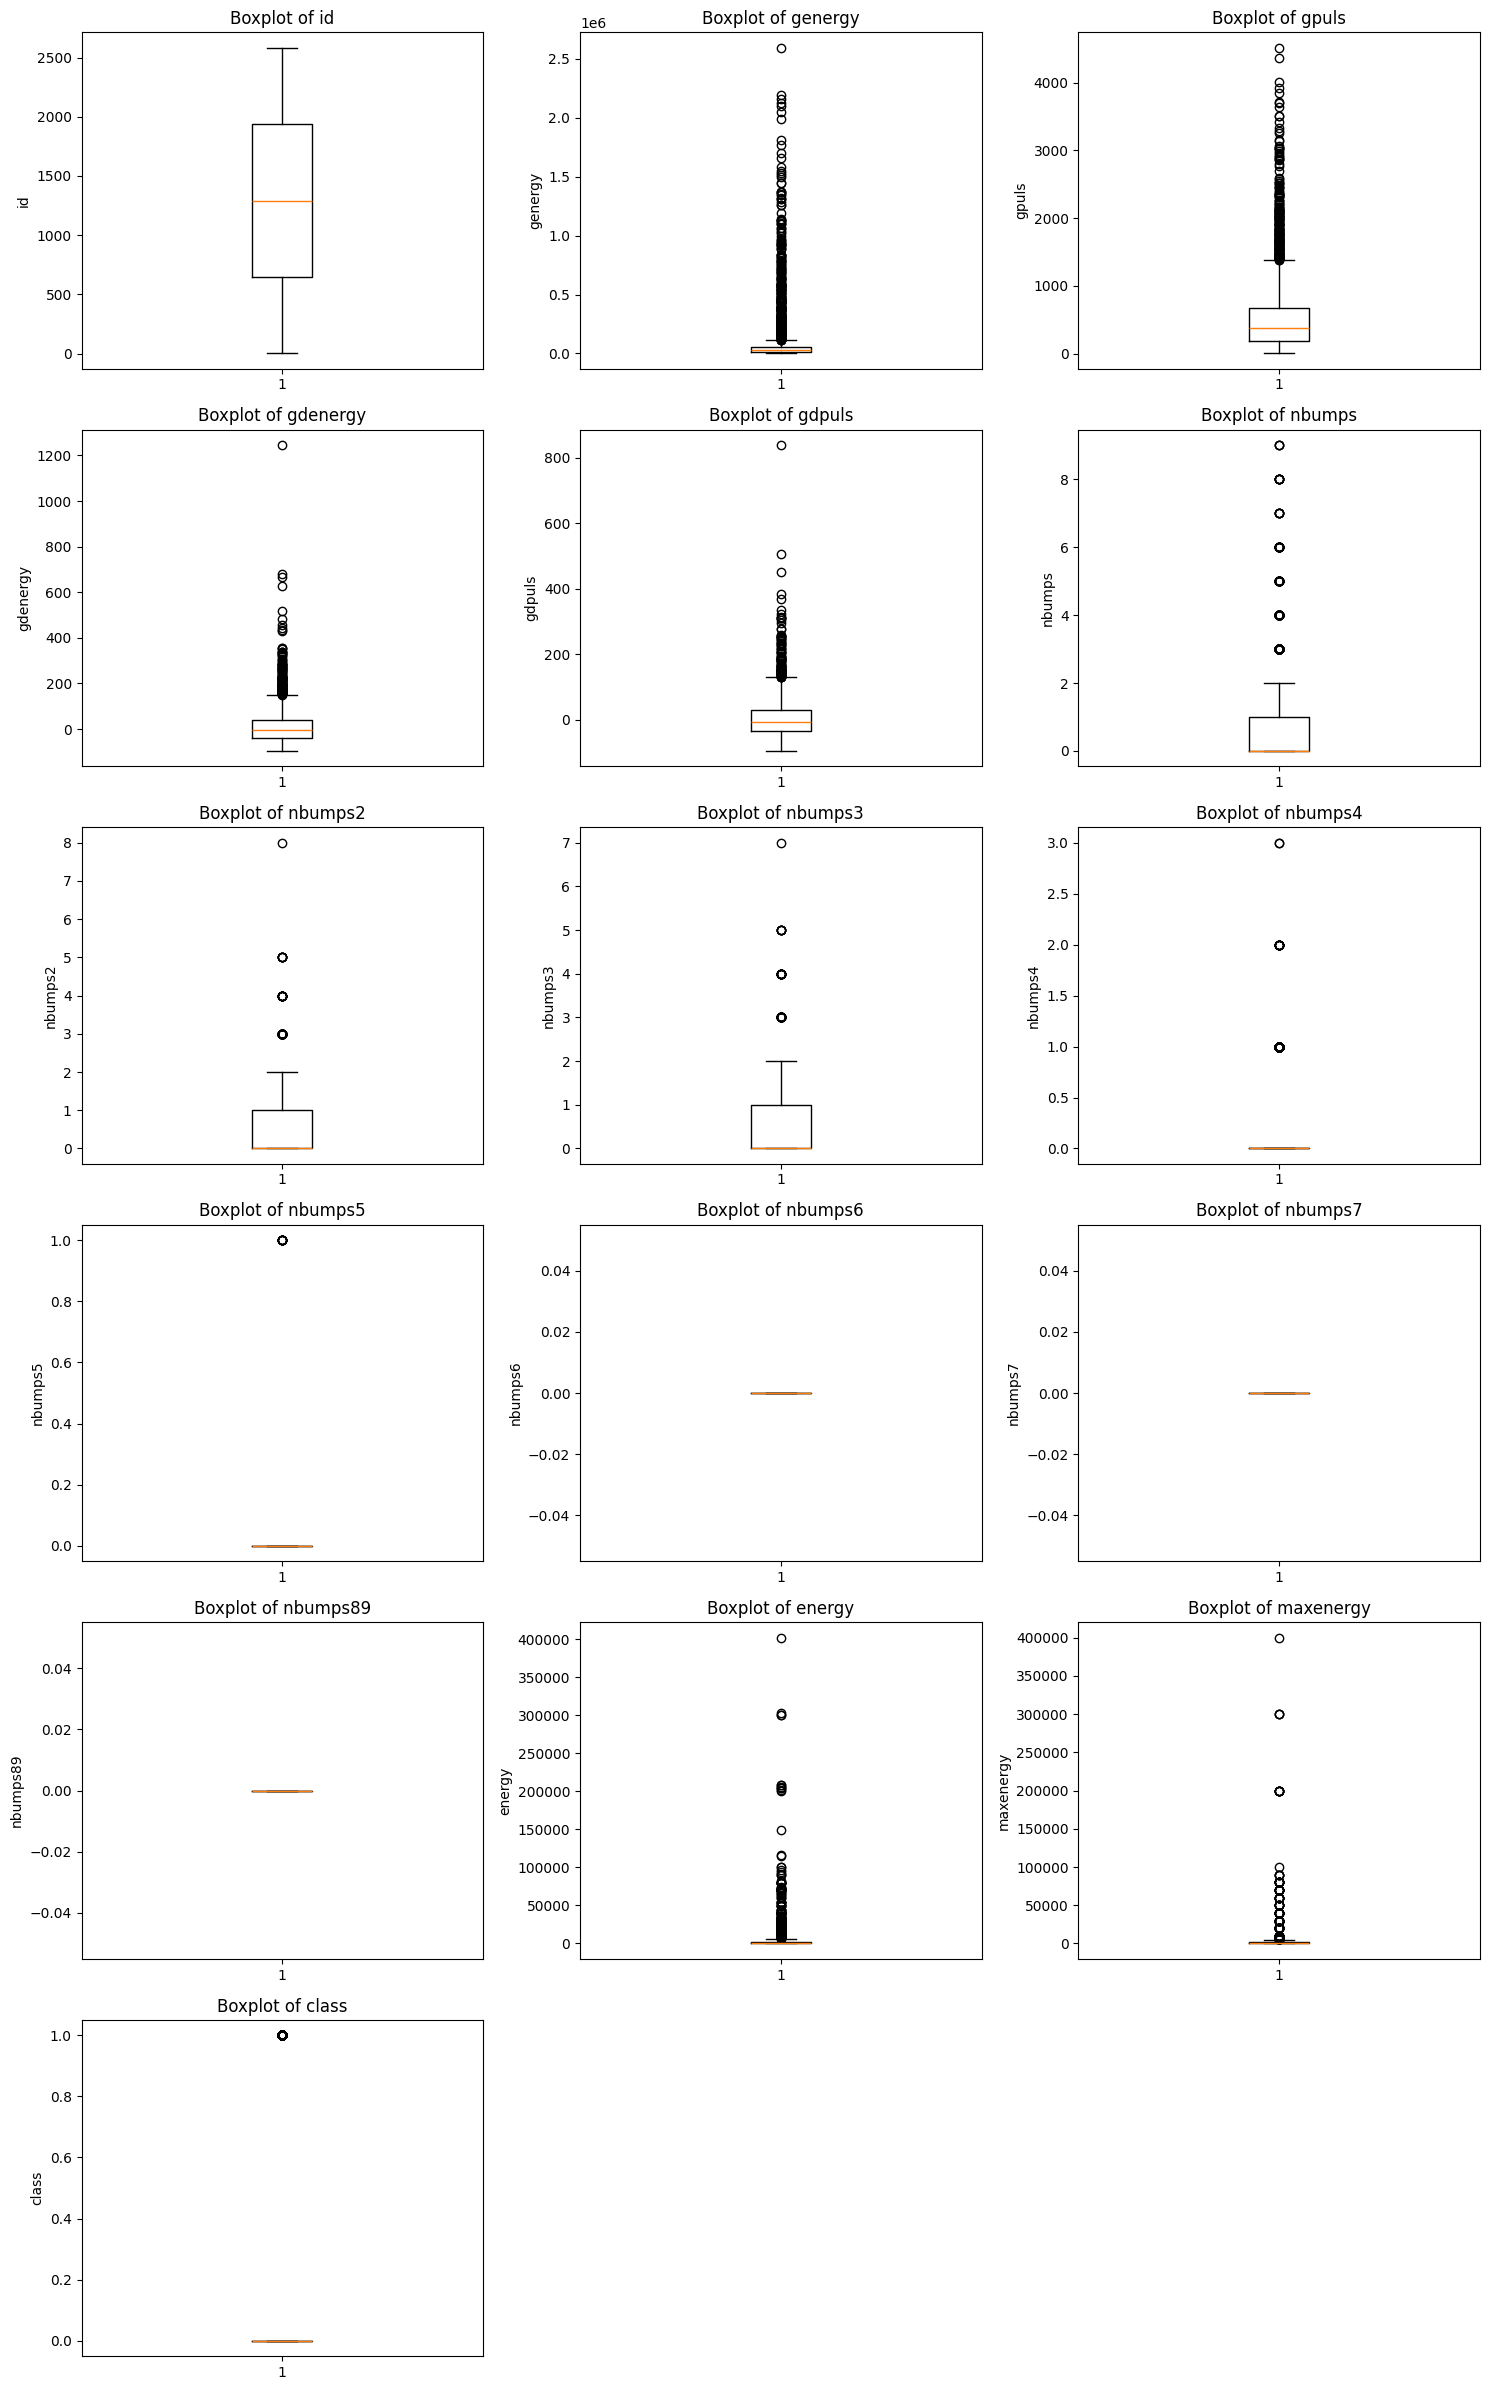

In [113]:
import math
# numerical columns
numerical_cols = df.select_dtypes('number').columns
# Calculate number of rows
n_rows = math.ceil(len(numerical_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

There are outliers in columns [generey,gpuls,gdenergy(has negative values), gdpuls(has negative values),energy,max_energy)

# Data Preprocessing

In [114]:
# take copy of data to keep original data unchanged
data=df.copy()

In [115]:
data.head()

,id,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,nbumps3,nbumps4,nbumps5,nbumps6,nbumps7,nbumps89,energy,maxenergy,class
0,1,a,a,N,15180,48,-72,-72,a,0,0,0,0,0,0,0,0,0,0,0
1,2,a,a,N,14720,33,-70,-79,a,1,0,1,0,0,0,0,0,2000,2000,0
2,3,a,a,N,8050,30,-81,-78,a,0,0,0,0,0,0,0,0,0,0,0
3,4,a,a,N,28820,171,-23,40,a,1,0,1,0,0,0,0,0,3000,3000,0
4,5,a,a,N,12640,57,-63,-52,a,0,0,0,0,0,0,0,0,0,0,0


## Feature Engineering

In [116]:
data.columns

Index(['id', 'seismic', 'seismoacoustic', 'shift', 'genergy', 'gpuls',
       'gdenergy', 'gdpuls', 'ghazard', 'nbumps', 'nbumps2', 'nbumps3',
       'nbumps4', 'nbumps5', 'nbumps6', 'nbumps7', 'nbumps89', 'energy',
       'maxenergy', 'class'],
      dtype='object')

Bump-count features

In [117]:
# if any row has any bump
data['has_any_bump']= (data['nbumps']>0).astype(int)
# if any row has bump89 because it has most energy class
data['has_high_energy_bump']= (data['nbumps89'] > 0).astype(int)

In [118]:
# High-energy bump columns
high_energy_cols=[
    'nbumps4',
    'nbumps5',
    'nbumps6',
    'nbumps7',
    'nbumps89'
]
# Number of high-energy bumps
data['high_energy_bumps']=data[high_energy_cols].sum(axis=1)
# Low-energy bump columns
low_energy_cols=[
    'nbumps2',
    'nbumps3'
]

# Number of low-energy bumps
data['low_energy_bumps']=data[low_energy_cols].sum(axis=1)

Energy feature

In [119]:
# high energy ratio
data['high_energy_ratio']=(
    data['high_energy_bumps'] /
    (data['nbumps']+ 1) # to avoid nbump=0
)
# Average energy per bump
data['avg_energy_per_bump']=(
    data['energy'] /
    (data['nbumps']+ 1)# to avoid nbump=0
)

# Energy per pulse
data['energy_per_pulse']=(
    data['genergy'] /
    (data['gpuls']+ 1)# to avoid nbump=0
)
# if deviation are positive means if hazard are larger than usual
data['both_positive_dev']=((data['gdenergy']>0)&(data['gdpuls']>0)).astype(int)
# if deviation are negative means if hazard are smaller than usual
data['both_negative_dev']=((data['gdenergy']<0)&(data['gdpuls']<0)).astype(int)
# the power of deviation
data['dev_magnitude']= np.sqrt(data['gdenergy']**2+data['gdpuls']**2)

Hazard assessment

In [120]:
# if three sources agree as same type of hazard
data['hazard_agreement']=(data['seismic']==data['seismoacoustic'])&(data['seismoacoustic']==data['ghazard'])

# if one of them say c or higher as high hazard
data['any_high_hazard']=(data[['seismic', 'seismoacoustic', 'ghazard']]=='c').any(axis=1).astype(int)

##  Handle outliers

In [121]:
data.columns

Index(['id', 'seismic', 'seismoacoustic', 'shift', 'genergy', 'gpuls',
       'gdenergy', 'gdpuls', 'ghazard', 'nbumps', 'nbumps2', 'nbumps3',
       'nbumps4', 'nbumps5', 'nbumps6', 'nbumps7', 'nbumps89', 'energy',
       'maxenergy', 'class', 'has_any_bump', 'has_high_energy_bump',
       'high_energy_bumps', 'low_energy_bumps', 'high_energy_ratio',
       'avg_energy_per_bump', 'energy_per_pulse', 'both_positive_dev',
       'both_negative_dev', 'dev_magnitude', 'hazard_agreement',
       'any_high_hazard'],
      dtype='object')

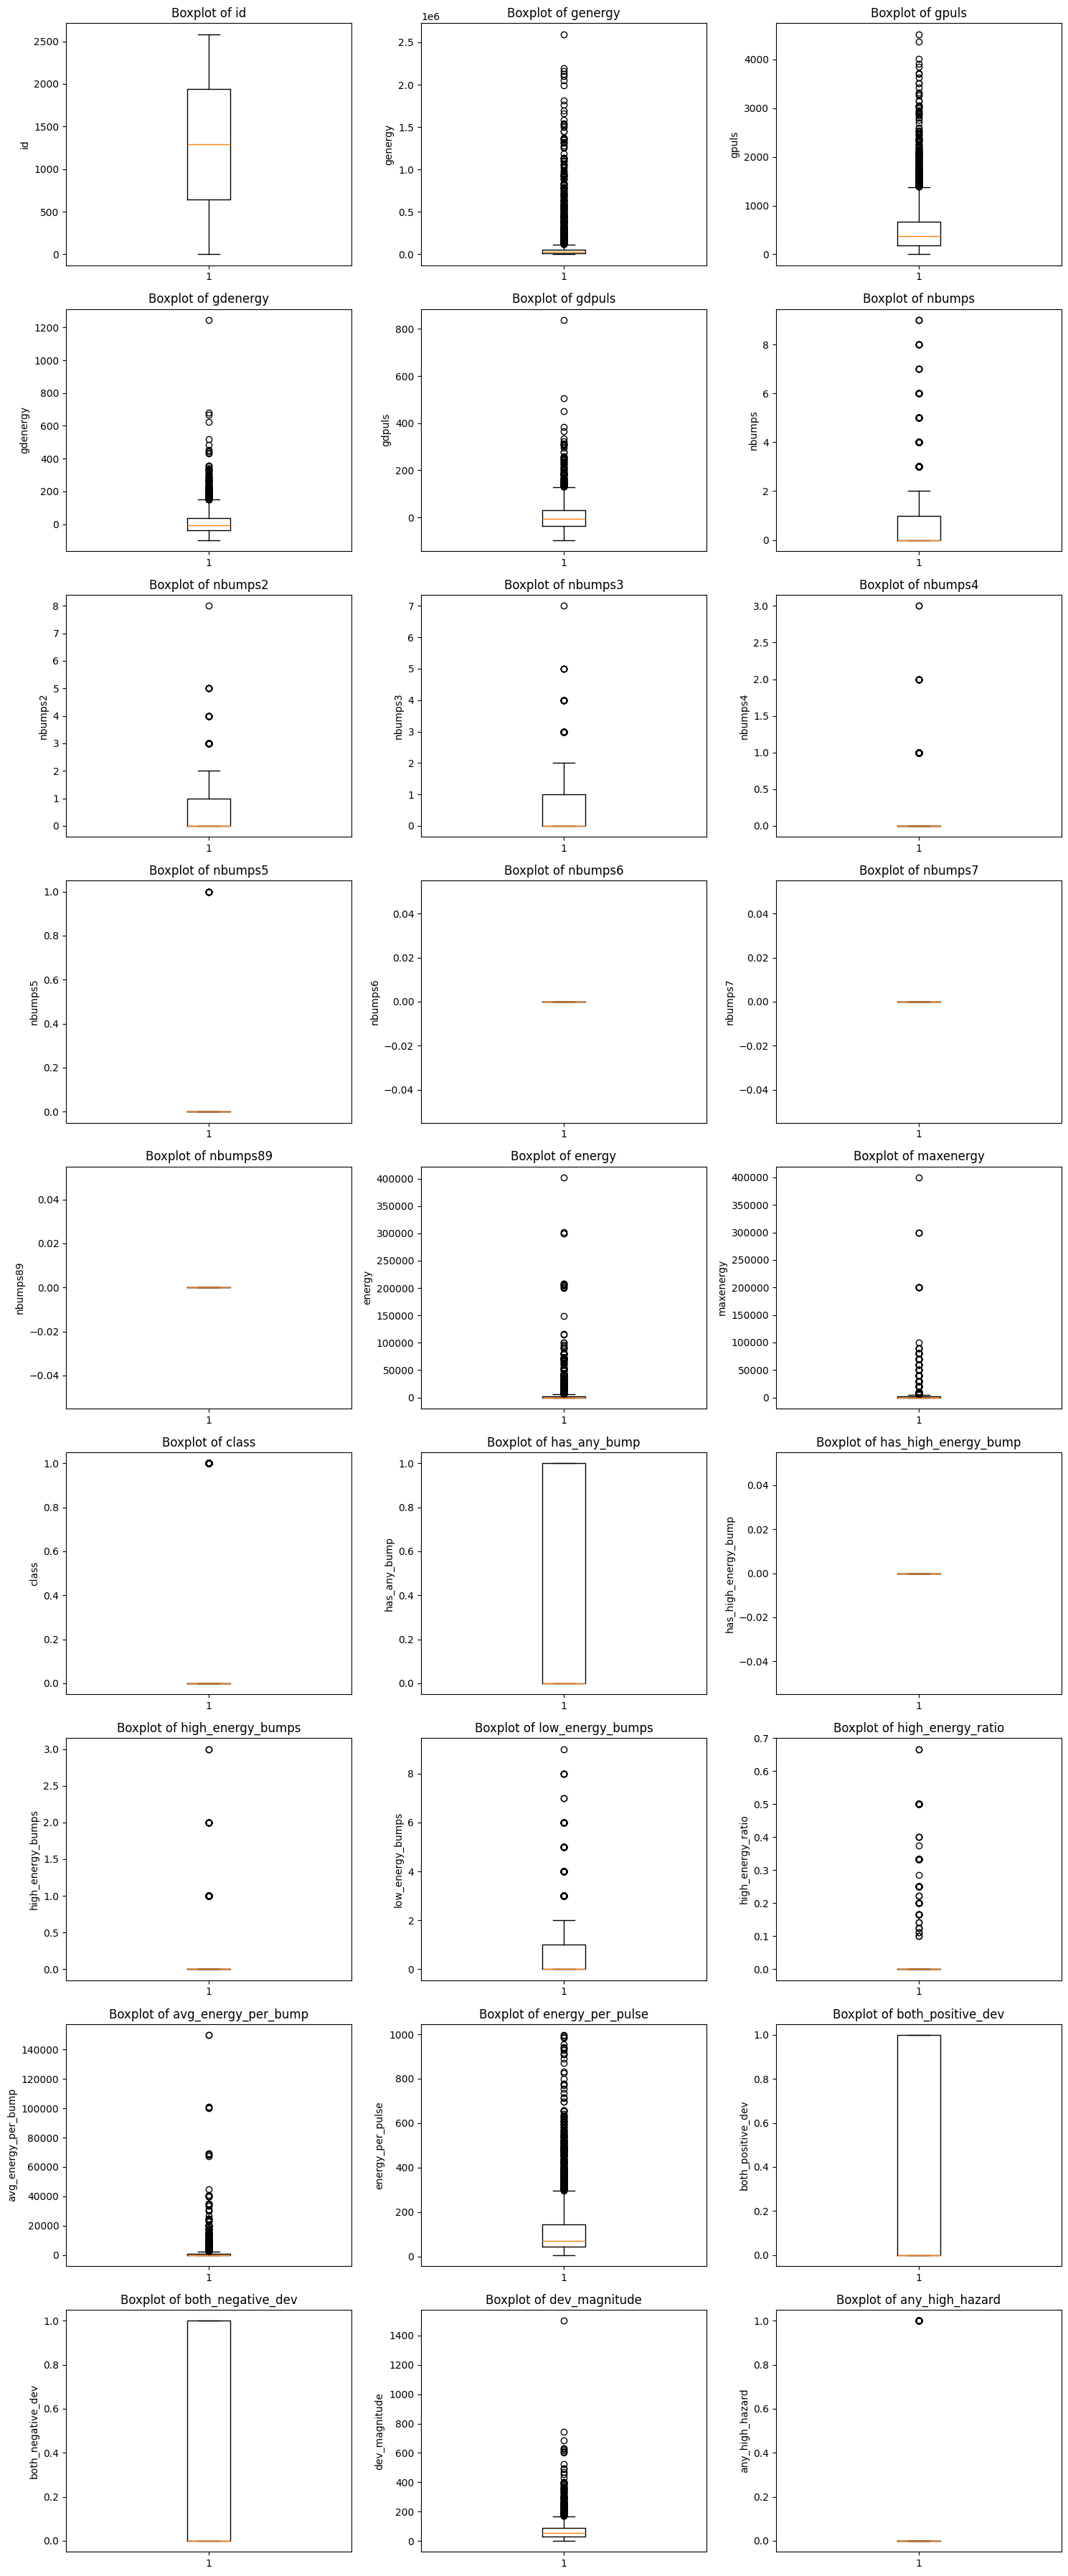

In [122]:
numerical_cols = data.select_dtypes('number').columns
# Calculate number of rows
n_rows = math.ceil(len(numerical_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(data[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

hist plot to check skewness

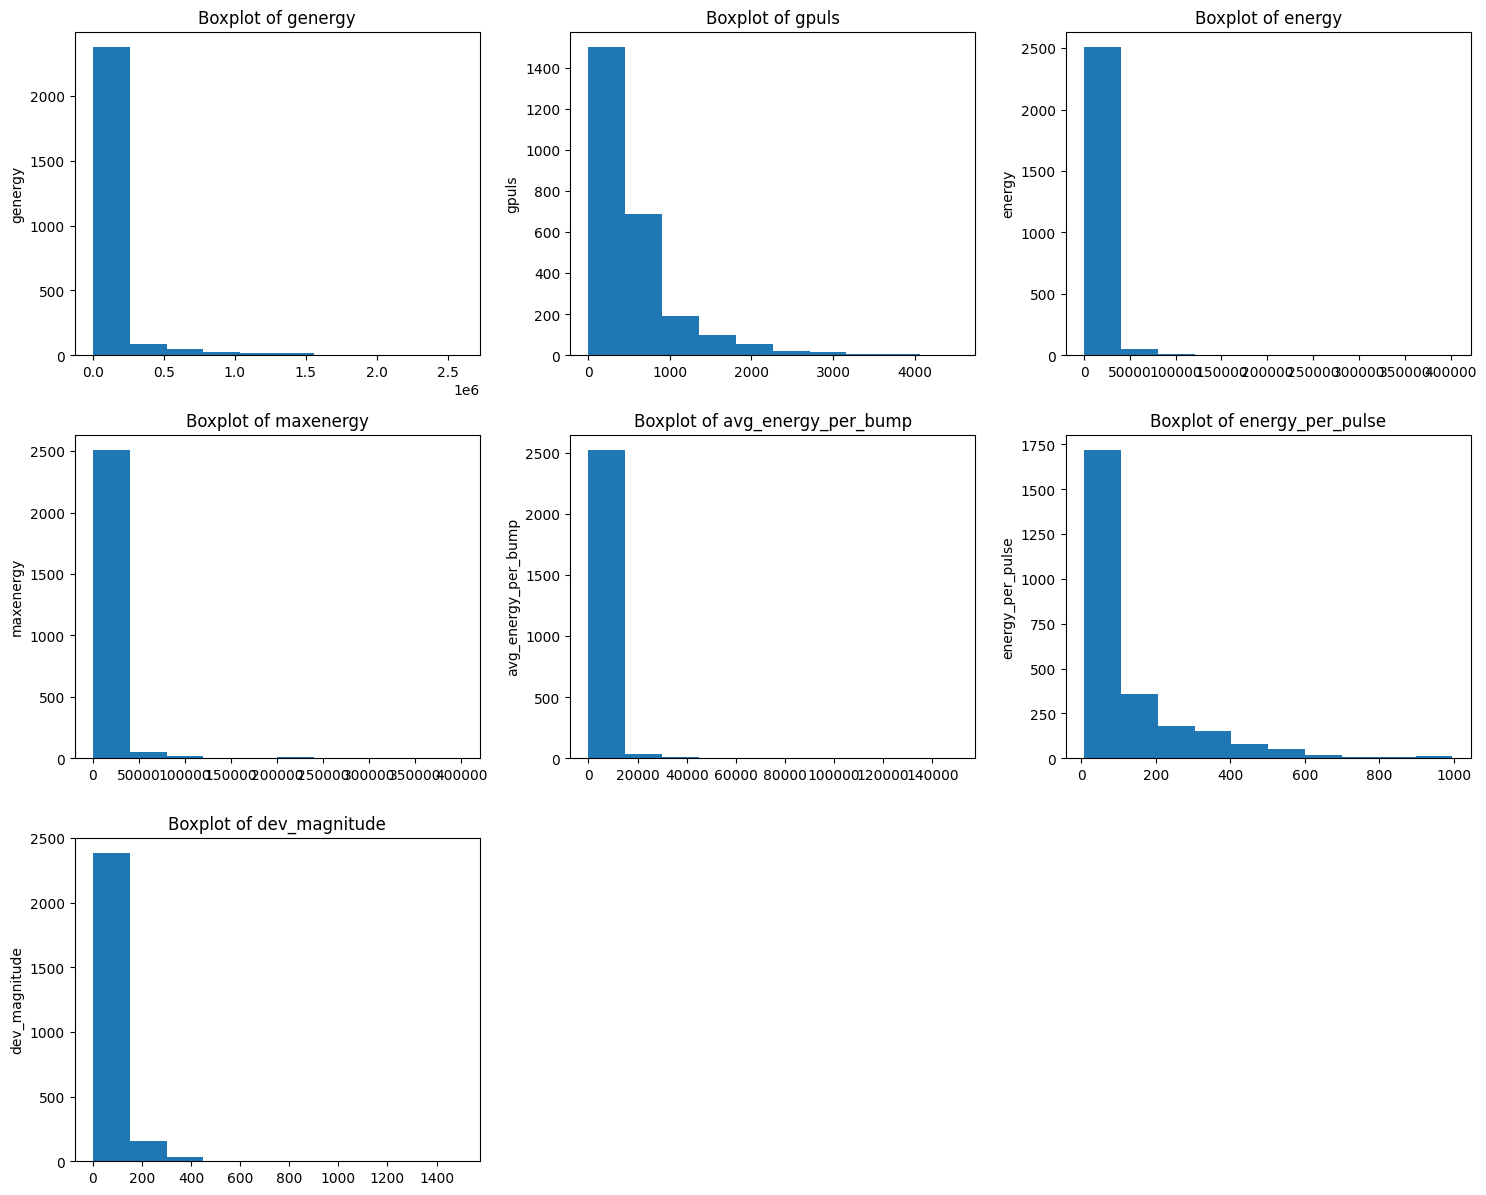

In [123]:
outliers_cols=['genergy', 'gpuls','energy', 'maxenergy','avg_energy_per_bump',
               'energy_per_pulse', 'dev_magnitude']
# check skeweness

# Calculate number of rows
n_rows = math.ceil(len(numerical_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(outliers_cols):
    axes[i].hist(data[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(outliers_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


In [124]:
data[outliers_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
genergy,2584.0,90242.523220,229200.508894,100.000000,11660.000000,25485.000000,52832.500000,2.595650e+06
gpuls,2584.0,538.579334,562.652536,2.000000,190.000000,379.000000,669.000000,4.518000e+03
energy,2584.0,4975.270898,20450.833222,0.000000,0.000000,0.000000,2600.000000,4.020000e+05
maxenergy,2584.0,4278.850619,19357.454882,0.000000,0.000000,0.000000,2000.000000,4.000000e+05
avg_energy_per_bump,2584.0,1586.377586,7139.888758,0.000000,0.000000,0.000000,1000.000000,1.500000e+05
energy_per_pulse,2584.0,132.390865,148.222429,7.163814,45.354047,70.286630,145.714428,9.967874e+02
dev_magnitude,2584.0,71.640636,74.029407,1.000000,31.890437,54.060147,86.886371,1.500756e+03


these histograms indicate all outliers columns are right skewed
I will use log1p to handle and transform outliers

In [125]:
for col in outliers_cols:
    data[col] = np.log1p(data[col])

Check outlier columns after transformation

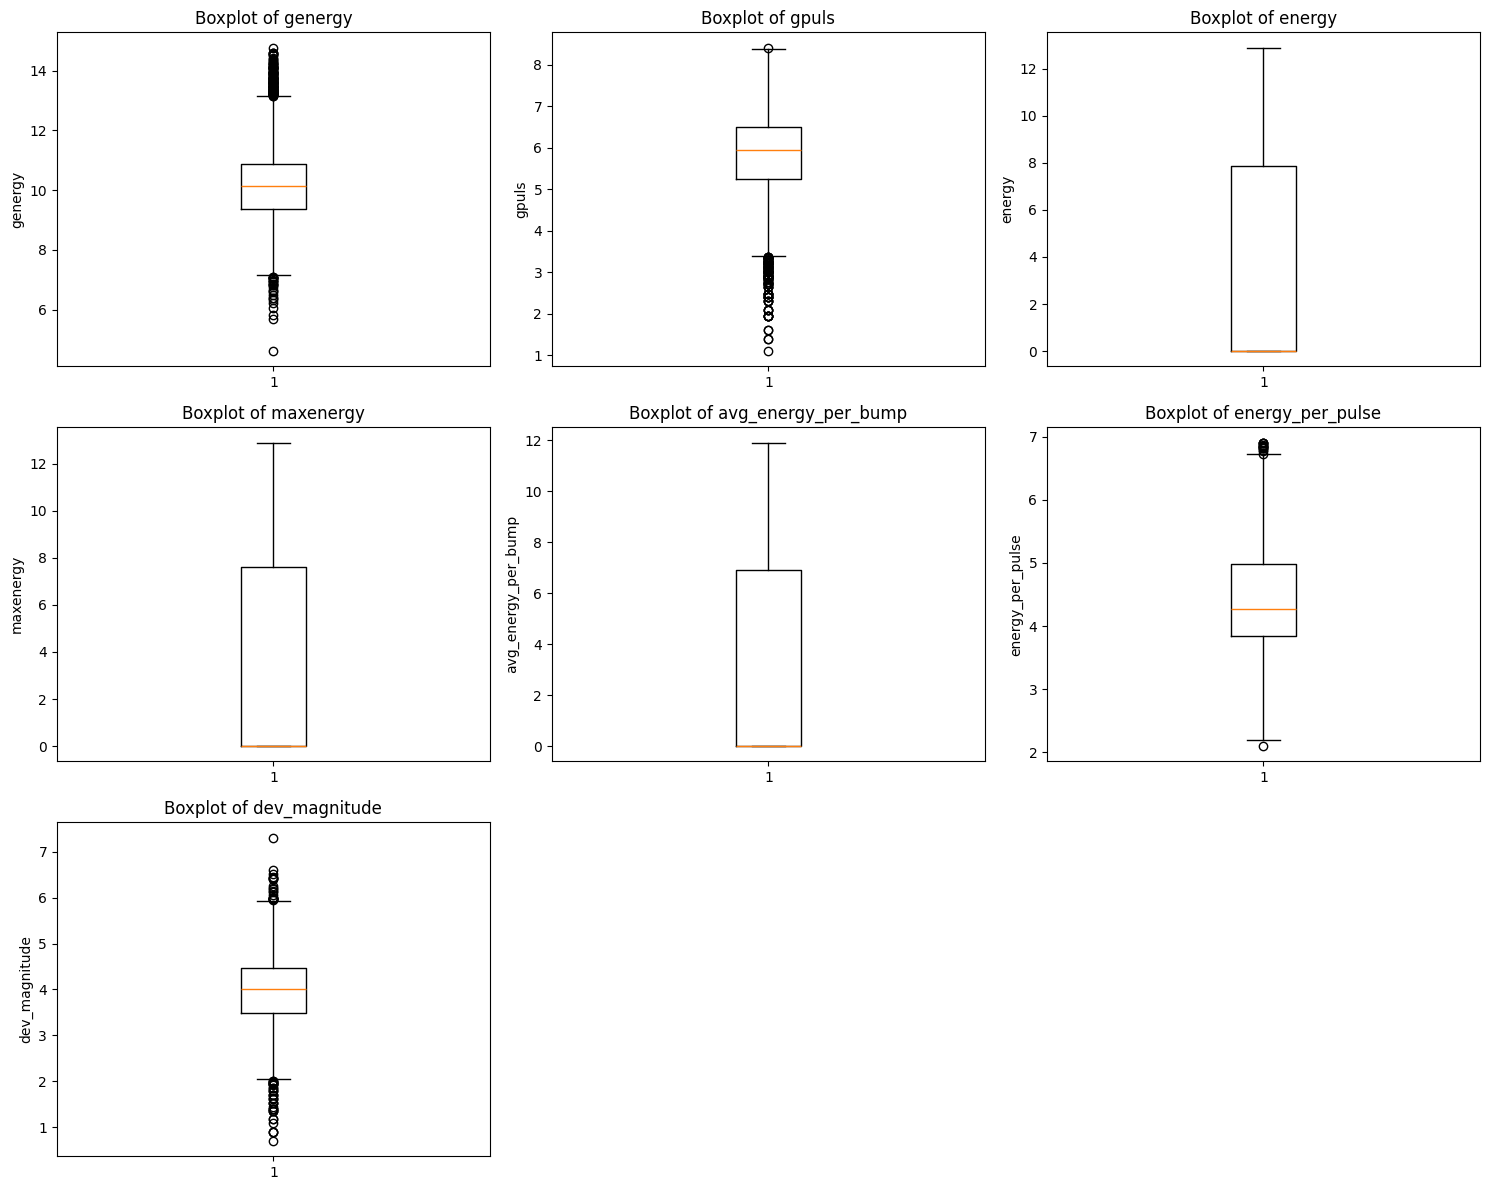

In [126]:
# Calculate number of rows
n_rows = math.ceil(len(outliers_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(outliers_cols):
    axes[i].boxplot(data[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(outliers_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [127]:
data[outliers_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
genergy,2584.0,10.221153,1.393800,4.615121,9.364005,10.145885,10.874899,14.769348
gpuls,2584.0,5.769602,1.160420,1.098612,5.252273,5.940171,6.507278,8.416046
energy,2584.0,3.481643,4.117081,0.000000,0.000000,0.000000,7.863651,12.904210
maxenergy,2584.0,3.398884,4.019217,0.000000,0.000000,0.000000,7.601402,12.899222
avg_energy_per_bump,2584.0,3.046380,3.609053,0.000000,0.000000,0.000000,6.908755,11.918397
energy_per_pulse,2584.0,4.467329,0.870472,2.099711,3.836309,4.266709,4.988488,6.905540
dev_magnitude,2584.0,3.962867,0.811721,0.693147,3.493182,4.008426,4.476044,7.314390


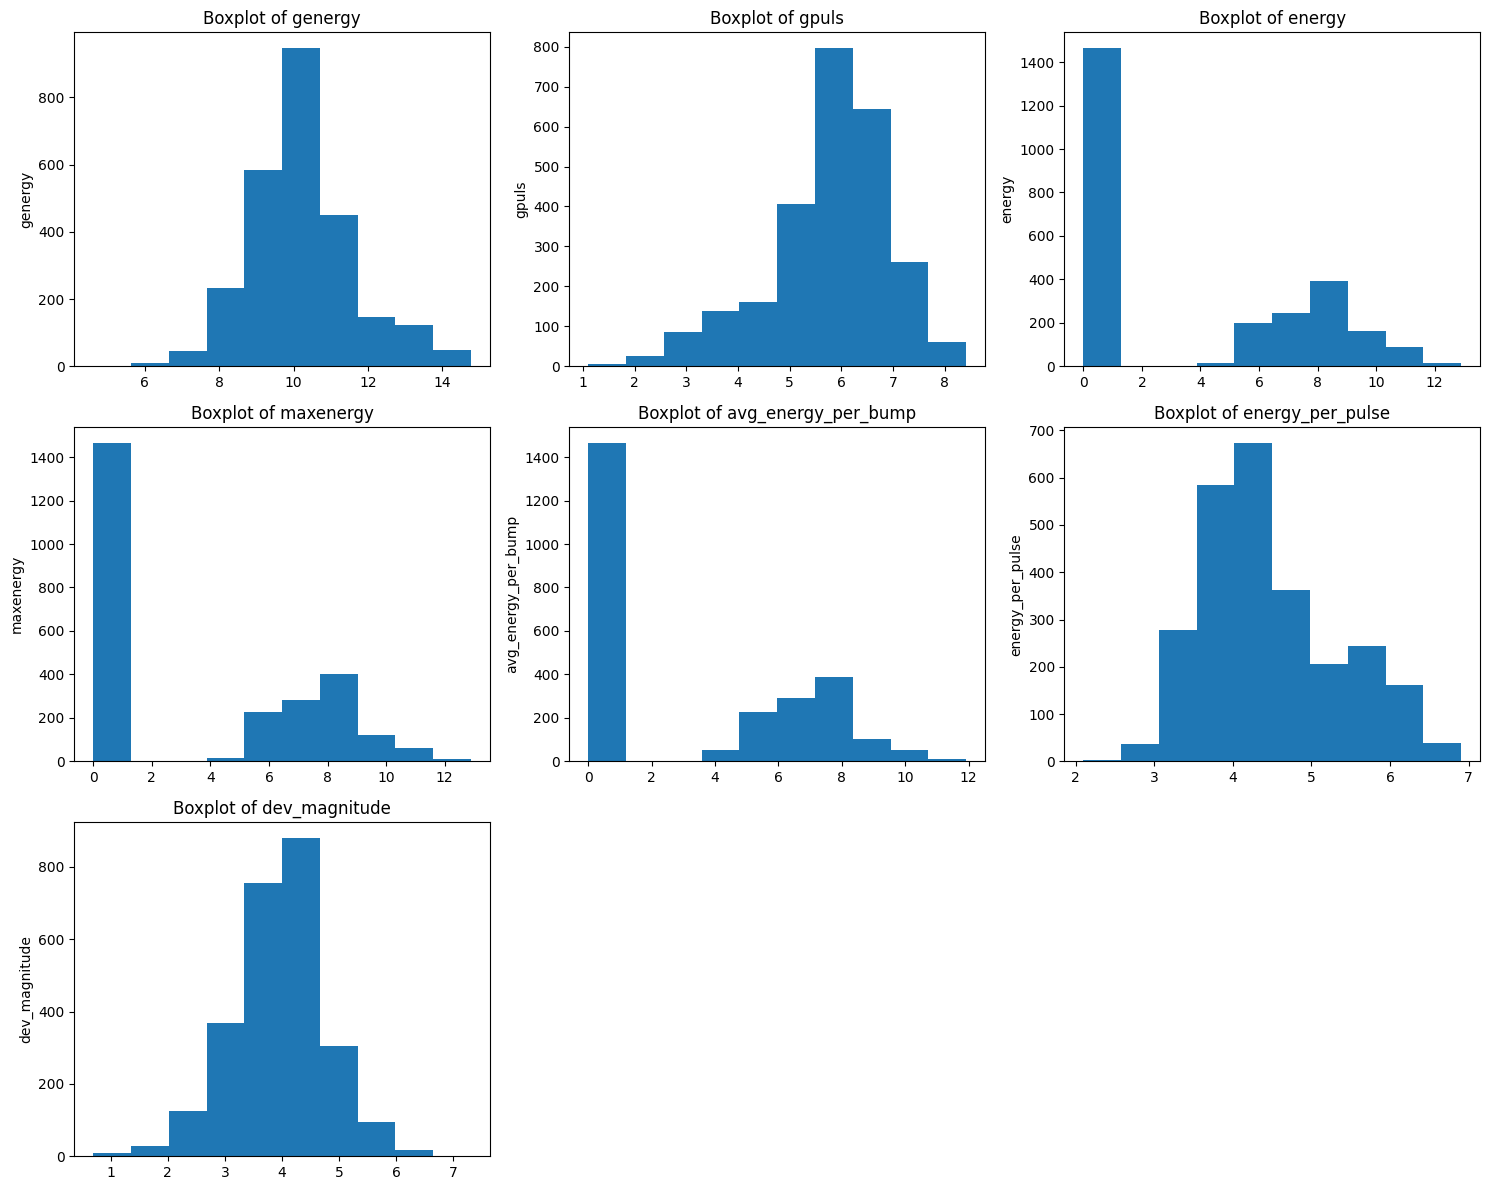

In [128]:
# check skeweness

# Calculate number of rows
n_rows = math.ceil(len(outliers_cols)/3)

# Create subplots
fig,axes = plt.subplots(
    n_rows,
    3,
    figsize=(15, 4 * n_rows)
)
# Flatten axes to make looping easier
axes = axes.flatten()
# make boxplot
for i, col in enumerate(outliers_cols):
    axes[i].hist(data[col])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Hide empty subplots
for i in range(len(outliers_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


In [129]:
data.head()

,id,seismic,seismoacoustic,shift,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,...,high_energy_bumps,low_energy_bumps,high_energy_ratio,avg_energy_per_bump,energy_per_pulse,both_positive_dev,both_negative_dev,dev_magnitude,hazard_agreement,any_high_hazard
0,1,a,a,N,9.627800,3.891820,-72,-72,a,0,...,0,0,0.0,0.000000,5.739136,0,1,4.633013,True,0
1,2,a,a,N,9.597030,3.526361,-70,-79,a,1,...,0,1,0.0,6.908755,6.072909,0,1,4.668623,True,0
2,3,a,a,N,8.993552,3.433987,-81,-78,a,0,...,0,0,0.0,0.000000,5.563284,0,1,4.731362,True,0
3,4,a,a,N,10.268860,5.147494,-23,40,a,1,...,0,1,0.0,7.313887,5.127281,0,0,3.853145,True,0
4,5,a,a,N,9.444701,4.060443,-63,-52,a,0,...,0,0,0.0,0.000000,5.388757,0,1,4.415080,True,0


Save data to make EDA

In [130]:
data.to_csv("clean_data_for_EDA.csv",index=False)
print(f"shape: {data.shape}")

shape: (2584, 32)


## Encoding

In [131]:
categorical_cols

Index(['seismic', 'seismoacoustic', 'shift', 'ghazard'], dtype='object')

In [132]:
for col in categorical_cols:
  print(df[col].value_counts())
  print('='*50)

seismic
a    1682
b     902
Name: count, dtype: int64
seismoacoustic
a    1580
b     956
c      48
Name: count, dtype: int64
shift
W    1663
N     921
Name: count, dtype: int64
ghazard
a    2342
b     212
c      30
Name: count, dtype: int64


In [133]:
from sklearn.preprocessing import OrdinalEncoder
hazard_cols=['seismic','seismoacoustic','ghazard']
encoder=OrdinalEncoder(categories=[['a','b'],['a','b','c'],['a','b','c']]) # seismic has a,b but other have a,b,c
data[hazard_cols]=encoder.fit_transform(data[hazard_cols])

In [134]:
data=pd.get_dummies(data,columns=['shift'],drop_first=True).astype(int)

In [135]:
data.head()

,id,seismic,seismoacoustic,genergy,gpuls,gdenergy,gdpuls,ghazard,nbumps,nbumps2,...,low_energy_bumps,high_energy_ratio,avg_energy_per_bump,energy_per_pulse,both_positive_dev,both_negative_dev,dev_magnitude,hazard_agreement,any_high_hazard,shift_W
0,1,0,0,9,3,-72,-72,0,0,0,...,0,0,0,5,0,1,4,1,0,0
1,2,0,0,9,3,-70,-79,0,1,0,...,1,0,6,6,0,1,4,1,0,0
2,3,0,0,8,3,-81,-78,0,0,0,...,0,0,0,5,0,1,4,1,0,0
3,4,0,0,10,5,-23,40,0,1,0,...,1,0,7,5,0,0,3,1,0,0
4,5,0,0,9,4,-63,-52,0,0,0,...,0,0,0,5,0,1,4,1,0,0


## Train-test split

In [136]:
X = data.drop('class', axis=1)
y = data['class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [137]:
print('shape of train data: ',X_train.shape)
print('shape of test data: ',X_test.shape)

shape of train data:  (2067, 31)
shape of test data:  (517, 31)


## Scalling

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Make SMOTE to handle imbalance data

In [139]:
# check imbalance
print(y_train.value_counts())
print(y_train.value_counts(normalize=True)*100)

class
0    1931
1     136
Name: count, dtype: int64
class
0    93.420416
1     6.579584
Name: proportion, dtype: float64


In [140]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(
    X_train_scaled,
    y_train
)

In [141]:
print("Before SMOTE:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True)*100)
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())
print(y_train_smote.value_counts(normalize=True)*100)

Before SMOTE:
class
0    1931
1     136
Name: count, dtype: int64
class
0    93.420416
1     6.579584
Name: proportion, dtype: float64

After SMOTE:
class
0    1931
1    1931
Name: count, dtype: int64
class
0    50.0
1    50.0
Name: proportion, dtype: float64
